<a href="https://colab.research.google.com/github/armyPNR/CS-AI-Assignment/blob/lab-search/AI_68_Uniform_Cost_Search_EX1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from collections import deque

In [ ]:
class Graph:

    def __init__(self, adjacency_list):
        self.adjacency_list = adjacency_list
        print("Input Graph:\n",self.adjacency_list)

    def get_neighbors(self, v):
        return self.adjacency_list[v]

    def uniformcost_algorithm(self, start_node, stop_node):

        open_list = set([start_node])
        closed_list = set([])

        # g contains current distances from start_node to all other nodes
        g = {}

        g[start_node] = 0

        # parents contains an adjacency map of all nodes
        parents = {}
        parents[start_node] = start_node

        while len(open_list) > 0:
            n = None
            t = None
            a=0
            b=0
            #print("----------------------------------")

            # find a node with the lowest value of f() - evaluation function
            for v in open_list:

                if n == None or g[v] < g[n] :
                    n = v;
                    #a=g[v] + self.h(v) # Removed heuristic call
                    #print(n,"has g(n) ---- ", a)


            print("----------------------------------")
            if n == None:
                print('Path does not exist!')
                return None


            if n == stop_node:
                reconst_path = []

                while parents[n] != n:
                    reconst_path.append(n)
                    n = parents[n]

                reconst_path.append(start_node)

                reconst_path.reverse()
                print("\n---------------//-------------------")
                #print("UNIFORM COST SEARCH")
                print('UNIFORM COST SEARCH: {}'.format(reconst_path))
                print('cost of the path is:',g[stop_node])
                return reconst_path


            r = 0
            print("Parent ",n)

            for (m, weight) in self.get_neighbors(n):

                r=r+1
                #print("neighbor", r)

                if m not in open_list and m not in closed_list:
                    open_list.add(m)
                    parents[m] = n
                    g[m] = g[n] + weight
                    #print("Parent ",n)
                    print(n,"->",m,"Neighbors",r,"",m,"path cost =",weight ," THEN g(n) neighbors is ",g[m], " (", g[n], "+", weight, ")" )
                    #print(weight)

                # otherwise, check if it's quicker to first visit n, then m
                # and if it is, update parent data and g data
                # and if the node was in the closed_list, move it to open_list
                else:
                    if g[m] > g[n] + weight:
                        g[m] = g[n] + weight
                        parents[m] = n
                        print(n,"->",m,"Neighbors",r,"",m,"path cost =",weight ," THEN g(n) neighbors is ",g[m], " (", g[n], "+", weight, ")" )
                        if m in closed_list:
                            closed_list.remove(m)
                            open_list.add(m)


            open_list.remove(n)
            closed_list.add(n)

        print('Path does not exist!')
        return None

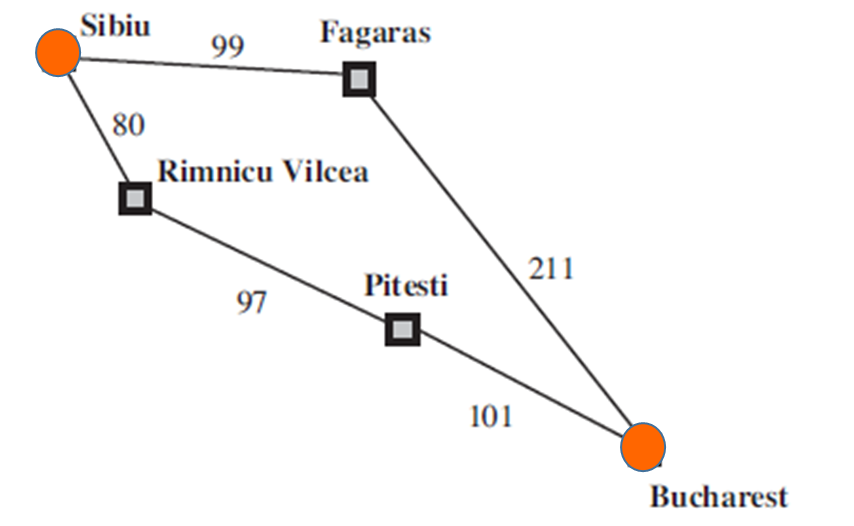

In [ ]:
adjacency_list_2 = {
    'S' : [('R',80),('F',99)],
    'R' : [('P',97)],
    'P' : [('B',101)],
    'F' : [('B',211)]
}


graph2 = Graph(adjacency_list_2)

Input Graph:
 {'S': [('R', 80), ('F', 99)], 'R': [('P', 97)], 'P': [('B', 101)], 'F': [('B', 211)]}


In [ ]:
graph2.uniformcost_algorithm('S', 'B')

----------------------------------
Parent  S
S -> R Neighbors 1  R path cost = 80  THEN g(n) neighbors is  80  ( 0 + 80 )
S -> F Neighbors 2  F path cost = 99  THEN g(n) neighbors is  99  ( 0 + 99 )
----------------------------------
Parent  R
R -> P Neighbors 1  P path cost = 97  THEN g(n) neighbors is  177  ( 80 + 97 )
----------------------------------
Parent  F
F -> B Neighbors 1  B path cost = 211  THEN g(n) neighbors is  310  ( 99 + 211 )
----------------------------------
Parent  P
P -> B Neighbors 1  B path cost = 101  THEN g(n) neighbors is  278  ( 177 + 101 )
----------------------------------

---------------//-------------------
UNIFORM COST SEARCH: ['S', 'R', 'P', 'B']
cost of the path is: 278


['S', 'R', 'P', 'B']